# Демонстрация работы модели

Загружаем PRD модель из MLFlow, и запускаем её на новых данных.

In [1]:
import sys
from pathlib import Path

def find_repo_root() -> Path:
    path = Path.cwd().resolve()
    for candidate in [path, *path.parents]:
        if (candidate / 'pyproject.toml').exists():
            return candidate
    raise RuntimeError('Could not find repo root (pyproject.toml).')

REPO_ROOT = find_repo_root()
STOCKS_DL_DIR = REPO_ROOT / 'stocks_dl'
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

In [2]:
from jupyter_utils import setup_jupyter_notebook

EXPERIMENT_NAME = 'sber_lstm_checkpoint'
setup_jupyter_notebook(environment='prod', experiment=EXPERIMENT_NAME)

Environment: prod
APP_CONFIG: config.toml
Tracking URI: http://localhost:5050
S3 endpoint: http://localhost:9050
Experiment: sber_lstm_checkpoint
Database: localhost:15432/stocks_advisor_db


In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from stocks_dl.workflows.inference import find_prd_run, run_demo_inference
from stocks_dl.artifacts.utils import download_artifact_file, find_analysis_run
from stocks_dl.data.pipeline import load_features_for_ticker

TICKER = 'SBER'

## Загрузка артефактов


In [4]:
prd_run_id, prd_summary = find_prd_run(TICKER, EXPERIMENT_NAME)
print('PRD run_id:', prd_run_id)
print('sequence_length:', prd_summary['sequence_length'])
print('batch_size:', prd_summary['batch_size'])

PRD run_id: e280eef90d4043109ae0a2a3cc7ded67
sequence_length: 16
batch_size: 8


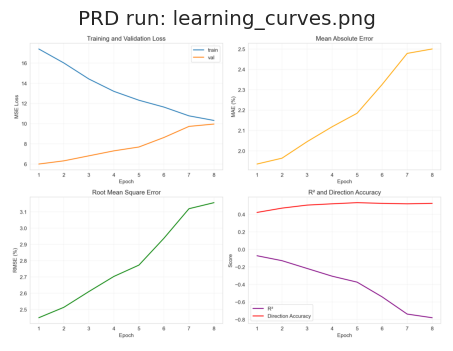

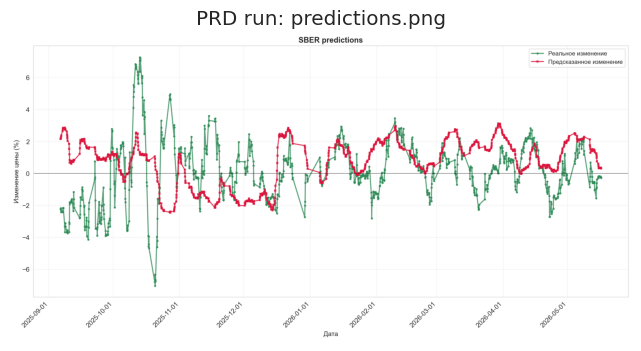

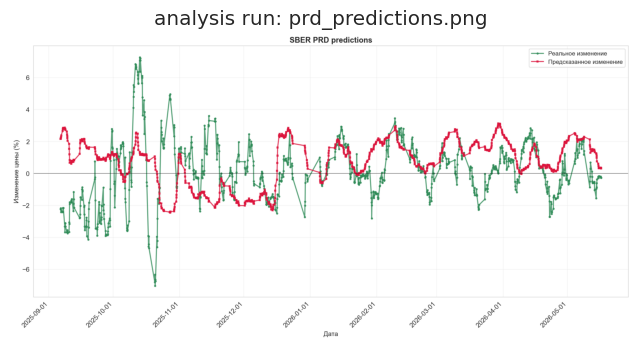

Skip direction_confusion_matrix.png: не найден в run 35129a2993bd4334b8746b2a36a1220a


In [5]:
for artifact_name in ('learning_curves.png', 'predictions.png'):
    img_path = download_artifact_file(prd_run_id, artifact_name)
    if img_path:
        plt.figure(figsize=(10, 4))
        plt.imshow(plt.imread(img_path))
        plt.axis('off')
        plt.title(f'PRD run: {artifact_name}')
        plt.show()
    else:
        print(f'PRD run: нет {artifact_name}')

analysis_run_id = find_analysis_run(prd_run_id, TICKER, EXPERIMENT_NAME)
for artifact_name in ('prd_predictions.png', 'direction_confusion_matrix.png'):
    run_id = analysis_run_id
    label = 'analysis'
    if not run_id:
        local_fallback = STOCKS_DL_DIR / artifact_name
        if local_fallback.exists():
            img_path = local_fallback
            label = 'local'
        else:
            print(f'Skip {artifact_name}: нет analysis run и файла {local_fallback}')
            continue
    else:
        img_path = download_artifact_file(run_id, artifact_name)

    if img_path:
        plt.figure(figsize=(10, 4))
        plt.imshow(plt.imread(img_path))
        plt.axis('off')
        plt.title(f'{label} run: {artifact_name}')
        plt.show()
    else:
        print(f'Skip {artifact_name}: не найден в run {run_id}')

## Запуск на новых данных и анализ прогнозов


In [6]:
features_df = load_features_for_ticker(TICKER)
demo_csv = STOCKS_DL_DIR / f'demo_{TICKER.lower()}_test.csv'
output_csv = STOCKS_DL_DIR / 'prd_demo_predictions.csv'

result = run_demo_inference(
    features_df=features_df,
    output_path=output_csv,
    ticker=TICKER,
    experiment_name=EXPERIMENT_NAME,
    demo_csv=demo_csv if demo_csv.exists() else None,
    prd_run_id=prd_run_id,
)

df = result['predictions_df']
print('Metrics:', result['metrics'])
print('Saved:', result['output_path'])
df.head(10)

/home/fiberfox/Projects/HSEAIMag2025/stocks-advisor/.venv/lib/python3.12/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.1 and num_layers=1
  warnings.warn(


Metrics: {'mae': 1.699303150177002, 'rmse': np.float32(2.2471697), 'r2': -0.4603409767150879, 'direction_accuracy': np.float64(0.5429951690821256)}
Saved: /home/fiberfox/Projects/HSEAIMag2025/stocks-advisor/mlflow/prd_demo_predictions.csv


,begin,target_price_change,predict,error,abs_error,direction_match
0,2025-09-16 10:00:00,-1.648406,2.201101,3.849507,3.849507,False
1,2025-09-16 12:00:00,-0.997208,2.155046,3.152254,3.152254,False
2,2025-09-16 14:00:00,-0.854758,2.113554,2.968312,2.968312,False
3,2025-09-16 16:00:00,-1.046011,2.066554,3.112566,3.112566,False
4,2025-09-16 18:00:00,-1.125828,2.129218,3.255046,3.255046,False
5,2025-09-17 10:00:00,-2.097832,2.221282,4.319114,4.319114,False
6,2025-09-17 12:00:00,-2.560361,2.194224,4.754584,4.754584,False
7,2025-09-17 14:00:00,-2.010484,2.187670,4.198153,4.198153,False
8,2025-09-17 16:00:00,-3.324925,2.044707,5.369633,5.369633,False
9,2025-09-17 18:00:00,-3.539270,1.925666,5.464937,5.464937,False


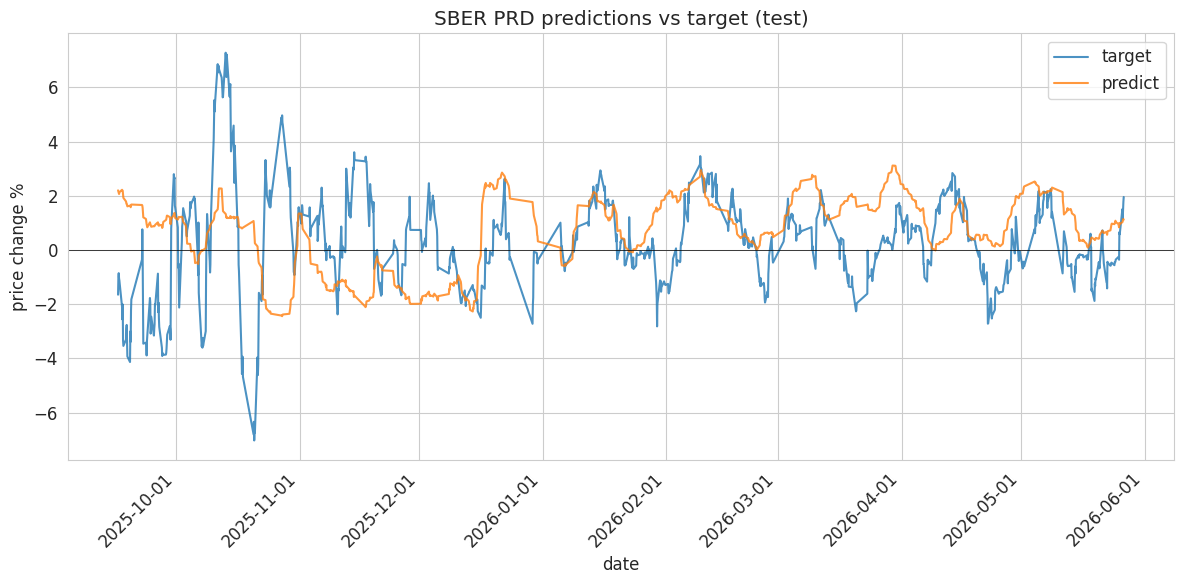

In [7]:
import matplotlib.dates as mdates

plot_df = df.copy()
if 'begin' in plot_df.columns:
    plot_df['begin'] = pd.to_datetime(plot_df['begin'])
    plot_df = plot_df.sort_values('begin')
    x = plot_df['begin']
else:
    plot_df = df
    x = range(len(plot_df))
plt.figure(figsize=(12, 6))
plt.plot(x, plot_df['target_price_change'].values, label='target', alpha=0.8)
plt.plot(x, plot_df['predict'].values, label='predict', alpha=0.8)
plt.axhline(0, color='black', linewidth=0.5)
plt.legend()
plt.title(f'{TICKER} PRD predictions vs target (test)')
plt.ylabel('price change %')
plt.xlabel('date')
if 'begin' in plot_df.columns:
    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [10]:
HORIZON_DAYS = 7
DEMO_LAST_DAYS = 3

recent = df.copy()
recent['begin'] = pd.to_datetime(recent['begin'])
cutoff = recent['begin'].max() - pd.Timedelta(days=DEMO_LAST_DAYS)
recent = recent.loc[recent['begin'] > cutoff].copy()

recent['horizon_date'] = recent['begin'] + pd.Timedelta(days=HORIZON_DAYS)

def direction_label(value: float) -> str:
    if value > 0:
        return 'рост'
    if value < 0:
        return 'падение'
    return 'боковик'

def match_label(row) -> str:
    if 'direction_match' in row:
        return 'совпало' if row['direction_match'] else 'не совпало'
    tgt = row.get('target_price_change', float('nan'))
    pred = row['predict']
    if pd.isna(tgt):
        return 'н/д'
    return 'совпало' if (pred > 0) == (tgt > 0) else 'не совпало'

demo_table = pd.DataFrame({
    'Дата и время': recent['begin'].dt.strftime('%Y-%m-%d %H:%M'),
    'Прогноз на дату и время': recent['horizon_date'].dt.strftime('%Y-%m-%d %H:%M'),
    'Ожидаемое изменение, %': recent['predict'].map(lambda x: f'{float(x):+.2f}'),
    'Фактическое изменение, %': recent['target_price_change'].map(lambda x: f'{float(x):+.2f}'),
    'Направление': recent['predict'].map(direction_label),
    'Результат': recent.apply(match_label, axis=1),
})

demo_table = demo_table.reset_index(drop=True)
demo_table

,Дата и время,Прогноз на дату и время,"Ожидаемое изменение, %","Фактическое изменение, %",Направление,Результат
0,2026-05-24 10:00,2026-05-31 10:00,+0.95,-0.56,рост,не совпало
1,2026-05-24 12:00,2026-05-31 12:00,+0.99,-0.45,рост,не совпало
2,2026-05-24 14:00,2026-05-31 14:00,+1.00,-0.45,рост,не совпало
3,2026-05-24 16:00,2026-05-31 16:00,+1.08,-0.43,рост,не совпало
4,2026-05-24 18:00,2026-05-31 18:00,+1.03,-0.35,рост,не совпало
5,2026-05-25 10:00,2026-06-01 10:00,+0.96,-0.26,рост,не совпало
6,2026-05-25 12:00,2026-06-01 12:00,+0.89,-0.28,рост,не совпало
7,2026-05-25 14:00,2026-06-01 14:00,+0.84,-0.36,рост,не совпало
8,2026-05-25 16:00,2026-06-01 16:00,+1.00,+0.66,рост,совпало
9,2026-05-25 18:00,2026-06-01 18:00,+0.95,+0.58,рост,совпало
